The notebook executes two main experiments:

### 1. Metric Optimization & Regularization Path
* Fits the `LogisticLassoFISTA` model across a grid of 50 regularization strengths ($\lambda$).
* Tracks and evaluates the model's performance on a validation set using multiple metrics: **Balanced Accuracy, F1 Score, ROC AUC, Precision, and Recall**.
* Generates plots to visualize the validation score paths for each metric.
* Plots the Lasso coefficient shrinkage path, dynamically highlighting the "best" $\lambda$ chosen by each metric.

### 2. Equivalence Check (FISTA vs. Sklearn)
* Fits both the custom FISTA model and Sklearn's `LogisticRegression` (using the `liblinear` solver) on a chosen equivalent penalty ($\lambda = 0.01$ ()defaults mapped to Sklearn's $C$).
* Performs a direct mathematical check by outputting the maximum absolute difference between the feature coefficients and intercepts learned by both models.
* Compares the final prediction match rate and test-set performance (Balanced Accuracy, F1, ROC AUC).

#### helper functions

In [7]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.models.logistic_lasso_fista import LogisticLassoFISTA

def load_and_prep_data(filepath="../data/gallstones.csv"):
    """Loads dataset and splits into Train/Valid/Test."""
    if not os.path.exists(filepath):
        print(f"Warning: {filepath} not found. Generating synthetic data for the experiment.")
        from sklearn.datasets import make_classification
        X, y = make_classification(n_samples=500, n_features=20, n_informative=5, random_state=42)
    else:
        df = pd.read_csv(filepath)
        X = df.drop(columns=['class']).values
        y = df['class'].values

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
    X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
    
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_valid_std = scaler.transform(X_valid)
    X_test_std = scaler.transform(X_test)
    
    return X_train_std, X_valid_std, X_test_std, y_train, y_valid, y_test

def run_metric_experiments(X_train, y_train, X_valid, y_valid):
    """Visualizes FISTA behavior when optimizing different metrics."""
    metrics_to_test = ["balanced_accuracy", "f1", "roc_auc", "precision", "recall"]
    
    print("="*60)
    print(" PART 1: FISTA METRIC OPTIMIZATION")
    print("="*60)

    fig_val, ax_val = plt.subplots(figsize=(8, 6))
    ax_val.set_title("Validation Paths Comparison")
    ax_val.set_xlabel("Lambda")
    ax_val.set_ylabel("Metric Score")
    ax_val.set_xscale("log")
    ax_val.grid(True, which="both", linestyle=":", linewidth=0.5)

    best_lambdas = {}
    last_fista_model = None

    for metric in metrics_to_test:
        print(f"\nEvaluating metric: {metric.upper()}")
        
        fista_model = LogisticLassoFISTA(standardize=False, max_iter=2000)

        fista_model.fit(
            X_train, y_train, 
            X_valid=X_valid, y_valid=y_valid, 
            metric=metric, 
            n_lambdas=50
        )
        
        print(f"  -> Best Lambda: {fista_model.best_lambda_:.6f}")
        print(f"  -> Best Validation {metric}: {fista_model.best_score_:.4f}")
        
        ax_val.plot(
            fista_model.lambdas_, 
            fista_model.validation_scores_, 
            marker='o', 
            markersize=4,
            label=metric
        )
        
        best_lambdas[metric] = fista_model.best_lambda_
        last_fista_model = fista_model

    ax_val.legend(loc='best')
    fig_val.tight_layout()

    fig_coef, ax_coef = last_fista_model.plot_coefficients()
    ax_coef.set_title("Lasso Coefficient Path with Best Lambdas per Metric")
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(best_lambdas)))
    
    for (metric, best_lam), color in zip(best_lambdas.items(), colors):
        ax_coef.axvline(
            best_lam, 
            color=color, 
            linestyle='--', 
            alpha=0.5,
            linewidth=2,
            label=f'{metric} ($\lambda$={best_lam:.5f})'
        )
        
    ax_coef.legend(loc='upper right', fontsize='small')
    fig_coef.tight_layout()
    
    plt.show()

def compare_fista_vs_sklearn(X_train, y_train, X_test, y_test, test_lambda=0.01):
    """Compares FISTA exactly against Sklearn's LogisticRegression."""
    print("\n" + "="*60)
    print(" PART 2: FISTA vs SKLEARN EQUIVALENCE CHECK")
    print("="*60)

    fista_model = LogisticLassoFISTA(standardize=True, max_iter=5000)
    fista_model.fit_single_lambda(X_train, y_train, lam=test_lambda)

    n_samples = X_train.shape[0]
    sklearn_C = 1.0 / (n_samples * test_lambda)
    
    sklearn_model = LogisticRegression(
        penalty='l1', 
        solver='liblinear',
        C=sklearn_C, 
        fit_intercept=True,
        random_state=42,
        max_iter=2000
    )
    sklearn_model.fit(X_train, y_train)
    
    fista_coefs = fista_model.coef_
    sklearn_coefs = sklearn_model.coef_[0]
    
    print(f"Testing at Lambda = {test_lambda} (Sklearn C = {sklearn_C:.4f})")
    print("-" * 60)
    print(f"{'Feature':<10} | {'FISTA Coef':<15} | {'Sklearn Coef':<15} | {'Diff':<15}")
    print("-" * 60)
    
    max_diff = 0
    counter = 0
    for i in range(len(fista_coefs)):
        diff = abs(fista_coefs[i] - sklearn_coefs[i])
        max_diff = max(max_diff, diff)
        # only print the first 10 features that are non-zero in either model
        if (fista_coefs[i] != 0 or sklearn_coefs[i] != 0):
            print(f"Feature {i:<3} | {fista_coefs[i]:>15.6f} | {sklearn_coefs[i]:>15.6f} | {diff:>15.6f}")
            counter += 1
            if counter >= 10:
                break
            
    print(f"... (Skipping remaining {len(fista_coefs)-counter} features)")
    print("-" * 60)
    print(f"Maximum absolute difference across ALL coefficients: {max_diff:.8f}")
    print(f"FISTA Intercept:   {fista_model.intercept_:.6f}")
    print(f"Sklearn Intercept: {sklearn_model.intercept_[0]:.6f}")
    
    fista_preds = (fista_model.predict_proba(X_test) > 0.5).astype(int)
    sklearn_preds = sklearn_model.predict(X_test)
    
    match_rate = np.mean(fista_preds == sklearn_preds) * 100
    print(f"\nPrediction Match Rate on Test Set: {match_rate:.2f}%")

    metrics = {
        "Balanced Accuracy": balanced_accuracy_score,
        "F1 Score": f1_score,
        "ROC AUC": roc_auc_score
    }
    print("\nTest Set Performance Comparison:")
    print("-" * 60)
    print(f"{'Metric':<20} | {'FISTA':<10} | {'Sklearn':<10} | {'Diff':<10}")
    print("-" * 60)
    for metric_name, metric_func in metrics.items():
        if metric_name == "ROC AUC":
            fista_score = metric_func(y_test, fista_model.predict_proba(X_test))
            sklearn_score = metric_func(y_test, sklearn_model.predict_proba(X_test)[:, 1])
        else:
            fista_score = metric_func(y_test, fista_preds)
            sklearn_score = metric_func(y_test, sklearn_preds)
        
        diff = abs(fista_score - sklearn_score)
        print(f"{metric_name:<20} | {fista_score:<10.4f} | {sklearn_score:<10.4f} | {diff:<10.4f}")
    print("-" * 60)

#### gallstones

 PART 1: FISTA METRIC OPTIMIZATION

Evaluating metric: BALANCED_ACCURACY
  -> Best Lambda: 0.000253
  -> Best Validation balanced_accuracy: 0.8281

Evaluating metric: F1
  -> Best Lambda: 0.000253
  -> Best Validation f1: 0.8308

Evaluating metric: ROC_AUC
  -> Best Lambda: 0.001192
  -> Best Validation roc_auc: 0.9219

Evaluating metric: PRECISION
  -> Best Lambda: 0.000253
  -> Best Validation precision: 0.8182

Evaluating metric: RECALL
  -> Best Lambda: 0.053634
  -> Best Validation recall: 0.8438


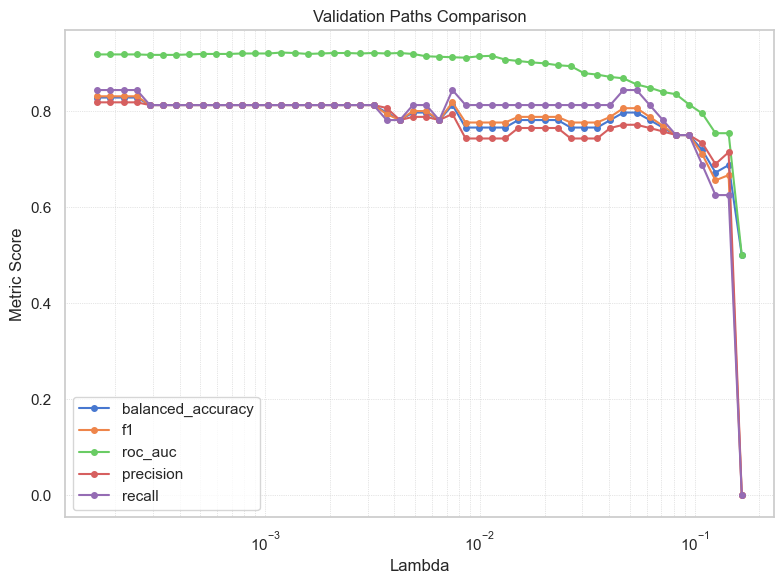

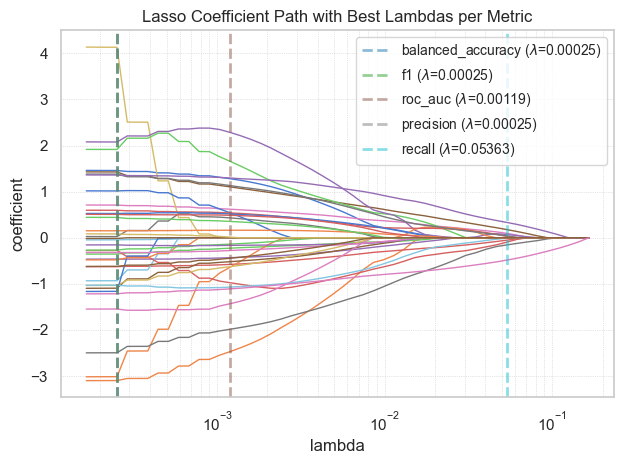


 PART 2: FISTA vs SKLEARN EQUIVALENCE CHECK
Testing at Lambda = 0.02 (Sklearn C = 0.2618)
------------------------------------------------------------
Feature    | FISTA Coef      | Sklearn Coef    | Diff           
------------------------------------------------------------
Feature 0   |        0.037631 |        0.031409 |        0.006222
Feature 2   |       -0.026134 |       -0.019589 |        0.006545
Feature 3   |       -0.202956 |       -0.218174 |        0.015217
Feature 4   |       -0.057722 |       -0.056498 |        0.001224
Feature 5   |        0.443939 |        0.426140 |        0.017799
Feature 6   |        0.264799 |        0.258083 |        0.006716
Feature 12  |        0.300735 |        0.267678 |        0.033057
Feature 13  |       -0.360755 |       -0.351653 |        0.009102
Feature 14  |        0.073737 |        0.046380 |        0.027357
Feature 17  |       -0.658126 |       -0.644380 |        0.013745
... (Skipping remaining 27 features)
-------------------------

In [8]:
X_tr, X_val, X_ts, y_tr, y_val, y_ts = load_and_prep_data("../data/gallstones.csv")
    
run_metric_experiments(X_tr, y_tr, X_val, y_val)
compare_fista_vs_sklearn(X_tr, y_tr, X_ts, y_ts, test_lambda=0.02)

#### musk

 PART 1: FISTA METRIC OPTIMIZATION

Evaluating metric: BALANCED_ACCURACY
  -> Best Lambda: 0.000149
  -> Best Validation balanced_accuracy: 0.8665

Evaluating metric: F1
  -> Best Lambda: 0.000149
  -> Best Validation f1: 0.7969

Evaluating metric: ROC_AUC
  -> Best Lambda: 0.000097
  -> Best Validation roc_auc: 0.9689

Evaluating metric: PRECISION
  -> Best Lambda: 0.048155
  -> Best Validation precision: 1.0000

Evaluating metric: RECALL
  -> Best Lambda: 0.000149
  -> Best Validation recall: 0.7598


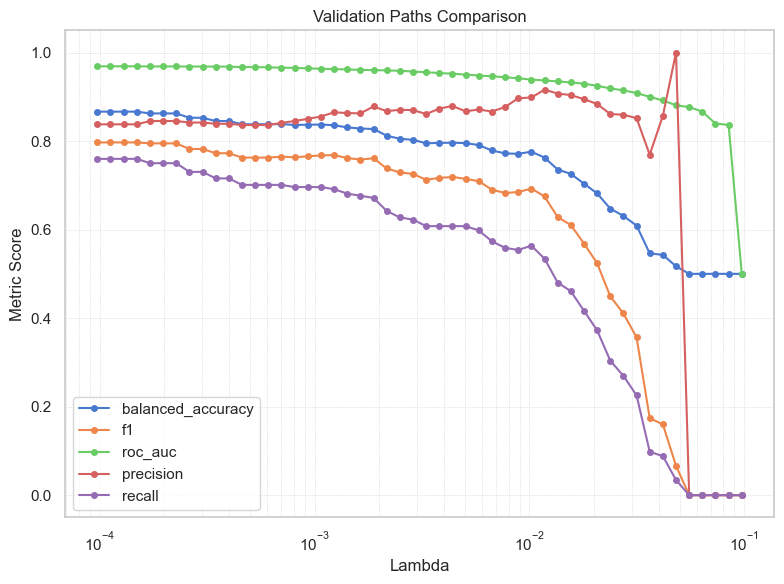

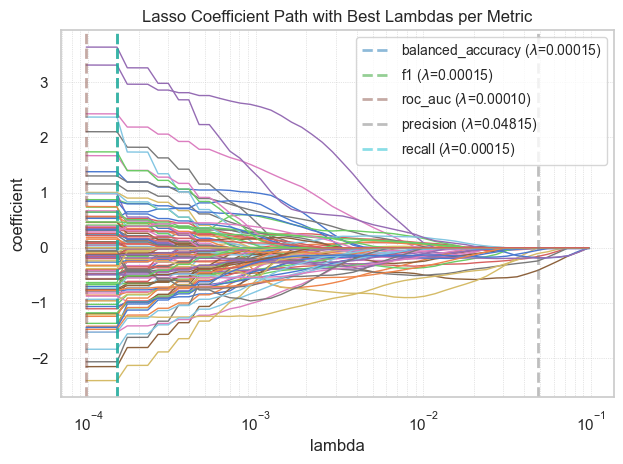


 PART 2: FISTA vs SKLEARN EQUIVALENCE CHECK
Testing at Lambda = 0.00015 (Sklearn C = 1.6844)
------------------------------------------------------------
Feature    | FISTA Coef      | Sklearn Coef    | Diff           
------------------------------------------------------------
Feature 0   |       -1.279032 |       -1.832174 |        0.553141
Feature 1   |       -0.099854 |       -0.142530 |        0.042677
Feature 2   |       -0.782067 |       -0.698390 |        0.083677
Feature 3   |       -0.832121 |       -1.038990 |        0.206868
Feature 4   |        0.125797 |        0.096197 |        0.029600
Feature 5   |       -0.732517 |       -0.745546 |        0.013029
Feature 6   |        0.013710 |        0.000000 |        0.013710
Feature 7   |        1.172401 |        1.144399 |        0.028002
Feature 8   |       -0.237410 |       -0.198429 |        0.038981
Feature 9   |       -1.069928 |       -0.904109 |        0.165819
... (Skipping remaining 124 features)
---------------------

In [9]:
X_tr, X_val, X_ts, y_tr, y_val, y_ts = load_and_prep_data("../data/musk.csv")
    
run_metric_experiments(X_tr, y_tr, X_val, y_val)
compare_fista_vs_sklearn(X_tr, y_tr, X_ts, y_ts, test_lambda=0.00015)

#### spectrometer

 PART 1: FISTA METRIC OPTIMIZATION

Evaluating metric: BALANCED_ACCURACY
  -> Best Lambda: 0.010188
  -> Best Validation balanced_accuracy: 0.9545

Evaluating metric: F1
  -> Best Lambda: 0.010188
  -> Best Validation f1: 0.9524

Evaluating metric: ROC_AUC
  -> Best Lambda: 0.048036
  -> Best Validation roc_auc: 1.0000

Evaluating metric: PRECISION
  -> Best Lambda: 0.031470
  -> Best Validation precision: 1.0000

Evaluating metric: RECALL
  -> Best Lambda: 0.010188
  -> Best Validation recall: 0.9091


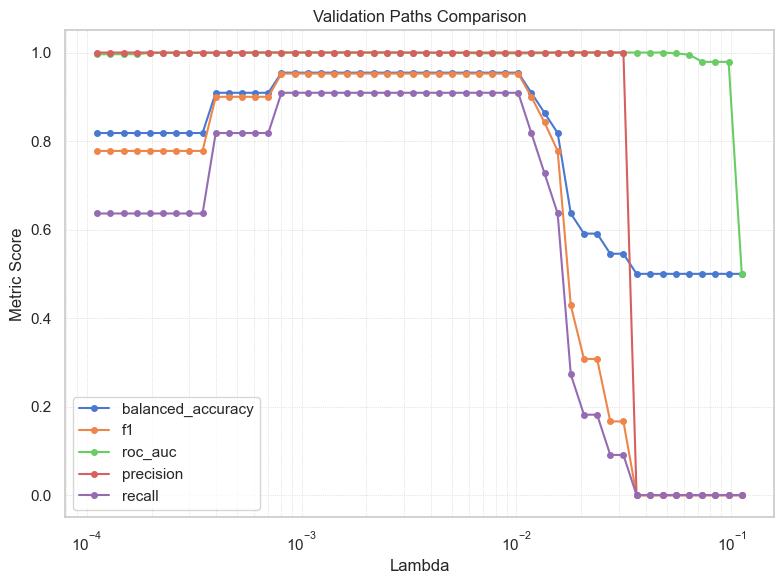

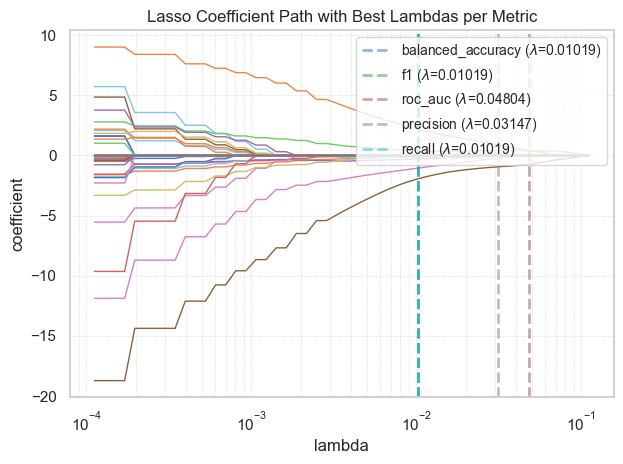


 PART 2: FISTA vs SKLEARN EQUIVALENCE CHECK
Testing at Lambda = 0.04 (Sklearn C = 0.0786)
------------------------------------------------------------
Feature    | FISTA Coef      | Sklearn Coef    | Diff           
------------------------------------------------------------
Feature 5   |       -0.781604 |       -0.392393 |        0.389212
Feature 6   |       -0.130117 |       -0.252295 |        0.122178
Feature 11  |        0.678240 |        0.548255 |        0.129985
Feature 32  |        0.306136 |        0.105383 |        0.200752
... (Skipping remaining 44 features)
------------------------------------------------------------
Maximum absolute difference across ALL coefficients: 0.38921151
FISTA Intercept:   -2.761948
Sklearn Intercept: -2.038949

Prediction Match Rate on Test Set: 100.00%

Test Set Performance Comparison:
------------------------------------------------------------
Metric               | FISTA      | Sklearn    | Diff      
---------------------------------------

In [10]:
X_tr, X_val, X_ts, y_tr, y_val, y_ts = load_and_prep_data("../data/spectrometer.csv")
    
run_metric_experiments(X_tr, y_tr, X_val, y_val)
compare_fista_vs_sklearn(X_tr, y_tr, X_ts, y_ts, test_lambda=0.04)

#### bioresponse

 PART 1: FISTA METRIC OPTIMIZATION

Evaluating metric: BALANCED_ACCURACY
  -> Best Lambda: 0.002648
  -> Best Validation balanced_accuracy: 0.7765

Evaluating metric: F1
  -> Best Lambda: 0.002300
  -> Best Validation f1: 0.8061

Evaluating metric: ROC_AUC
  -> Best Lambda: 0.006169
  -> Best Validation roc_auc: 0.8527

Evaluating metric: PRECISION
  -> Best Lambda: 0.002648
  -> Best Validation precision: 0.7793

Evaluating metric: RECALL
  -> Best Lambda: 0.241025
  -> Best Validation recall: 1.0000


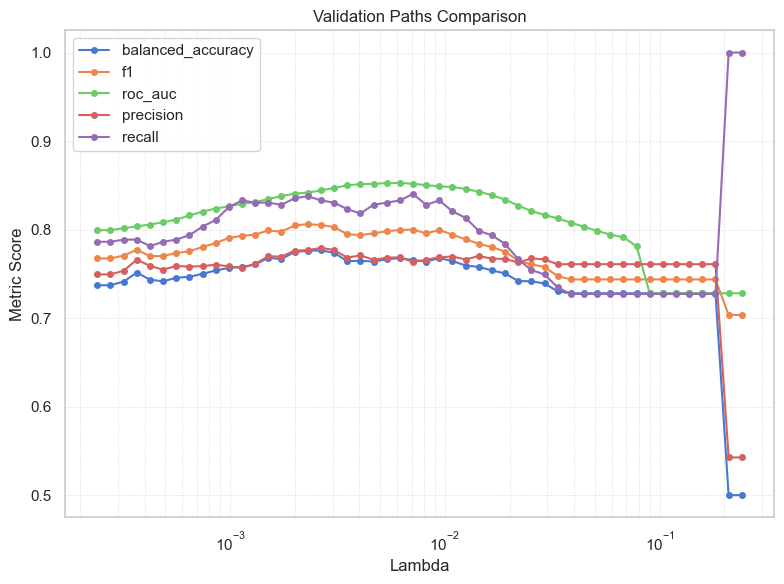

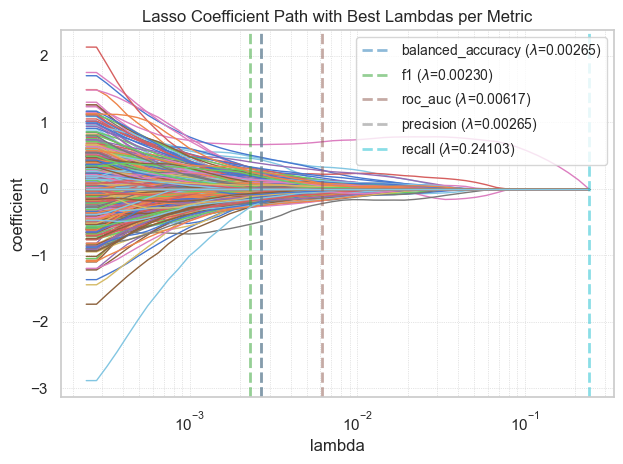


 PART 2: FISTA vs SKLEARN EQUIVALENCE CHECK
Testing at Lambda = 0.01 (Sklearn C = 0.0444)
------------------------------------------------------------
Feature    | FISTA Coef      | Sklearn Coef    | Diff           
------------------------------------------------------------
Feature 9   |        0.290340 |        0.282662 |        0.007677
Feature 13  |        0.037403 |        0.040570 |        0.003168
Feature 17  |        0.035574 |        0.035894 |        0.000320
Feature 26  |        0.739105 |        0.740983 |        0.001878
Feature 40  |       -0.102140 |       -0.116161 |        0.014021
Feature 50  |        0.005910 |        0.004755 |        0.001156
Feature 59  |       -0.010587 |       -0.015144 |        0.004557
Feature 65  |        0.013248 |        0.013578 |        0.000330
Feature 77  |        0.104857 |        0.087423 |        0.017434
Feature 80  |        0.173279 |        0.174772 |        0.001493
... (Skipping remaining 1740 features)
-----------------------

In [11]:
X_tr, X_val, X_ts, y_tr, y_val, y_ts = load_and_prep_data("../data/bioresponse.csv")
    
run_metric_experiments(X_tr, y_tr, X_val, y_val)
compare_fista_vs_sklearn(X_tr, y_tr, X_ts, y_ts, test_lambda=0.01)

### task 3

In [19]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.models.unlabeled_logreg import UnlabeledLogReg
from src.models.logistic_lasso_fista import LogisticLassoFISTA
from src.data_preparation import mcar, generate_missing

sns.set_theme(style="whitegrid", palette="muted")

In [18]:
def load_and_prep_data(filepath="../data/gallstones.csv"):
    """Loads dataset and standardizes features (required for generate_missing)."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"{filepath} not found. Please verify the path.")
        
    df = pd.read_csv(filepath)
    X = df.drop(columns=['class'])
    y = df['class'].values
    
    scaler = StandardScaler()
    X_std = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    
    df_std = X_std.copy()
    df_std['class'] = y
    
    return df_std, X_std, y

def evaluate_model(X_train, y_obs_train, X_valid, y_valid, X_test, y_test, method="mean"):
    """Fits the UnlabeledLogReg model and returns test metrics."""
    model = UnlabeledLogReg(completion_method=method, knn_k=5, max_iter=1000)
    model.fit(X_train, y_obs_train, X_valid=X_valid, y_valid=y_valid, metric="balanced_accuracy", n_lambdas=20)
    
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)

    return {
        "balanced_accuracy": balanced_accuracy_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs)
    }

df_std, X_std, y_true = load_and_prep_data("../data/gallstones.csv")

#### Missingness Rate vs. Model Performance (mean imputation)

In [17]:
missing_fractions = np.linspace(0.1, 0.9, 9)
results_exp1 = []

imputation_method = "mean"

for c in missing_fractions:
    print(f"Running missingness fraction: {c:.2f}")
    
    df_mcar, _, _ = mcar(df_std, c=c)
    df_mar1, _, _, _, _ = generate_missing(c, df_std, column_index=0, mode="MAR")
    df_mar2, _, _, _, _ = generate_missing(c, df_std, mode="MAR")
    df_mnar, _, _, _, _ = generate_missing(c, df_std, mode="MNAR", y_strength_scale=2.0)
    
    datasets = {"MCAR": df_mcar, "MAR1": df_mar1, "MAR2": df_mar2, "MNAR": df_mnar}
    
    for mech, df_masked in datasets.items():
        X_masked = df_masked.drop(columns=['class_observed']).values
        y_obs = df_masked['class_observed'].values
        
        # split: 60% train, 20% valid, 20% test
        X_tr, X_temp, y_tr, y_temp, yt_true, ytemp_true = train_test_split(
            X_masked, y_obs, y_true, test_size=0.4, random_state=42, stratify=y_true
        )
        X_va, X_ts, y_va, y_ts, yva_true, yts_true = train_test_split(
            X_temp, y_temp, ytemp_true, test_size=0.5, random_state=42, stratify=ytemp_true
        )
        
        metrics = evaluate_model(X_tr, y_tr, X_va, yva_true, X_ts, yts_true, method=imputation_method)
        
        results_exp1.append({
            "Missingness_Fraction": c,
            "Mechanism": mech,
            "Balanced_Accuracy": metrics["balanced_accuracy"],
            "F1_Score": metrics["f1"],
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "Roc_AUC": metrics["roc_auc"]
        })

df_res1 = pd.DataFrame(results_exp1)
print("\n--- Summary Table: Missingness Rates (Balanced Accuracy) ---")
display(df_res1.pivot(index="Missingness_Fraction", columns="Mechanism", values="Balanced_Accuracy"))


Running missingness fraction: 0.10
Running missingness fraction: 0.20
Running missingness fraction: 0.30
Running missingness fraction: 0.40
Running missingness fraction: 0.50
Running missingness fraction: 0.60
Running missingness fraction: 0.70
Running missingness fraction: 0.80
Running missingness fraction: 0.90

--- Summary Table: Missingness Rates (Balanced Accuracy) ---


Mechanism,MAR1,MAR2,MCAR,MNAR
Missingness_Fraction,,,,
0.1,0.797165,0.734604,0.732649,0.746823
0.2,0.733627,0.628543,0.719453,0.743891
0.3,0.695503,0.600196,0.585044,0.614370
0.4,0.662268,0.601173,0.663245,0.587488
0.5,0.567449,0.635386,0.615836,0.583578
0.6,0.510264,0.555718,0.586999,0.535191
0.7,0.569892,0.541544,0.568426,0.567449
0.8,0.501955,0.516129,0.500000,0.500978
0.9,0.500000,0.517107,0.500000,0.516129


#### FISTA plots

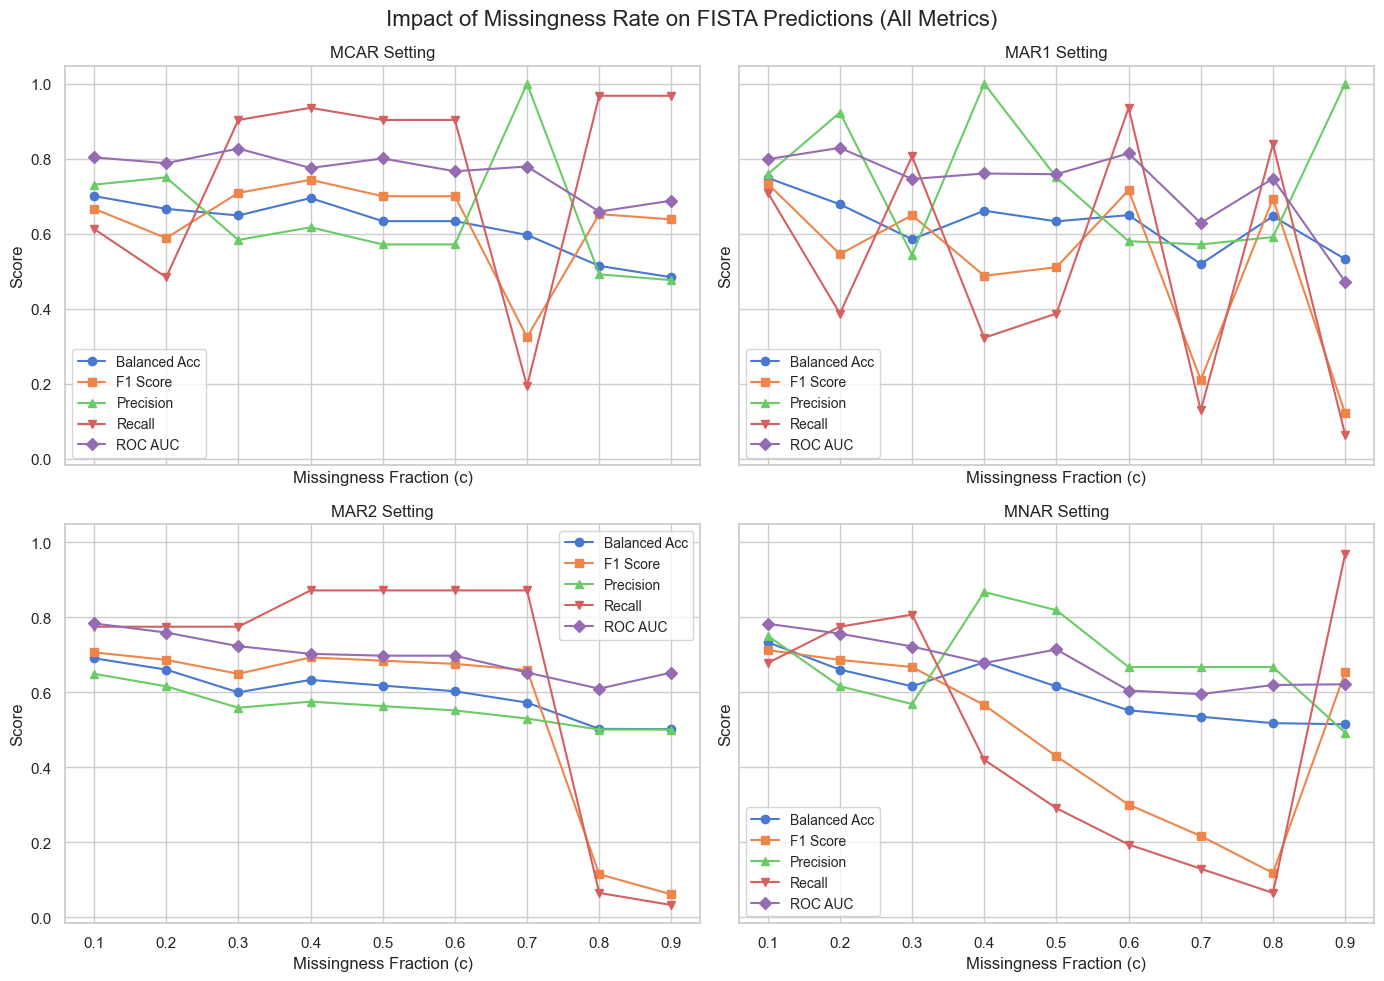

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

mechanisms = ["MCAR", "MAR1", "MAR2", "MNAR"]

for ax, mech in zip(axes, mechanisms):
    subset = df_res1[df_res1["Mechanism"] == mech]
    
    ax.plot(subset["Missingness_Fraction"], subset["Balanced_Accuracy"], marker='o', label='Balanced Acc')
    ax.plot(subset["Missingness_Fraction"], subset["F1_Score"], marker='s', label='F1 Score')
    ax.plot(subset["Missingness_Fraction"], subset["Precision"], marker='^', label='Precision')
    ax.plot(subset["Missingness_Fraction"], subset["Recall"], marker='v', label='Recall')
    ax.plot(subset["Missingness_Fraction"], subset["Roc_AUC"], marker='D', label='ROC AUC')
    
    ax.set_title(f"{mech} Setting")
    ax.set_xlabel("Missingness Fraction (c)")
    ax.set_ylabel("Score")
    ax.legend(fontsize='small', loc='best')

plt.suptitle("Impact of Missingness Rate on FISTA Predictions (All Metrics)", fontsize=16)
plt.tight_layout()
plt.show()

#### MAR1 Feature Choice & MAR2 Beta Uniformity & MNAR Y-strength

In [15]:
c_fixed = 0.30
results_exp2 = []
completion_methods = ["mean", "knn_mean"]

print(f"Running Imputation comparisons at missingness = {c_fixed}...")

# ---------------------------------------------------------
# A. MAR1: Impact of single variable choice
# ---------------------------------------------------------

feature_indices_to_test = [0, 2, 4, 6, 8] if df_std.shape[1] > 9 else range(min(5, df_std.shape[1]-1))

for f_idx in feature_indices_to_test:
    df_mar1, _, _, _, _ = generate_missing(c_fixed, df_std, column_index=f_idx, mode="MAR")
    X_masked = df_mar1.drop(columns=['class_observed']).values
    y_obs = df_mar1['class_observed'].values
    
    X_tr, X_temp, y_tr, y_temp, yt_true, ytemp_true = train_test_split(X_masked, y_obs, y_true, test_size=0.4, random_state=42)
    X_va, X_ts, y_va, y_ts, yva_true, yts_true = train_test_split(X_temp, y_temp, ytemp_true, test_size=0.5, random_state=42)
    
    for method in completion_methods:
        metrics = evaluate_model(X_tr, y_tr, X_va, yva_true, X_ts, yts_true, method=method)
        results_exp2.append({
            "Setting": f"MAR1 (Feature {f_idx})",
            "Category": "MAR1 Variable Choice",
            "Imputation": method,
            "Balanced_Accuracy": metrics["balanced_accuracy"]
        })

# ---------------------------------------------------------
# B. MAR2: Uniform vs Random Betas 
# ---------------------------------------------------------
for seed in [42, 100, 999]:
    rng = np.random.default_rng(seed)
    
    # Uniform
    df_mar2_uni, _, _, _, _ = generate_missing(c_fixed, df_std, mode="MAR", rng=rng)
    # Random
    random_betas = rng.uniform(0.1, 1.5, size=df_std.shape[1]-1)
    df_mar2_rnd, _, _, _, _ = generate_missing(c_fixed, df_std, betas_x=random_betas, mode="MAR", rng=rng)
    
    for name, df_masked in [("MAR2 (Uniform)", df_mar2_uni), ("MAR2 (Random)", df_mar2_rnd)]:
        X_masked = df_masked.drop(columns=['class_observed']).values
        y_obs = df_masked['class_observed'].values
        
        X_tr, X_temp, y_tr, y_temp, yt_true, ytemp_true = train_test_split(X_masked, y_obs, y_true, test_size=0.4, random_state=seed)
        X_va, X_ts, y_va, y_ts, yva_true, yts_true = train_test_split(X_temp, y_temp, ytemp_true, test_size=0.5, random_state=seed)
        
        for method in completion_methods:
            metrics = evaluate_model(X_tr, y_tr, X_va, yva_true, X_ts, yts_true, method=method)
            results_exp2.append({
                "Setting": name,
                "Category": "MAR2 Distribution",
                "Imputation": method,
                "Balanced_Accuracy": metrics["balanced_accuracy"]
            })

# ---------------------------------------------------------
# C. MNAR: Varying Y-Strength
# ---------------------------------------------------------
y_strengths = [0.5, 1.0, 2.0, 5.0]
for y_str in y_strengths:
    df_mnar, _, _, _, _ = generate_missing(c_fixed, df_std, mode="MNAR", y_strength_scale=y_str)
    X_masked = df_mnar.drop(columns=['class_observed']).values
    y_obs = df_mnar['class_observed'].values
    
    X_tr, X_temp, y_tr, y_temp, yt_true, ytemp_true = train_test_split(X_masked, y_obs, y_true, test_size=0.4, random_state=42)
    X_va, X_ts, y_va, y_ts, yva_true, yts_true = train_test_split(X_temp, y_temp, ytemp_true, test_size=0.5, random_state=42)
    
    for method in completion_methods:
        metrics = evaluate_model(X_tr, y_tr, X_va, yva_true, X_ts, yts_true, method=method)
        results_exp2.append({
            "Setting": f"MNAR (Y-Scale {y_str})",
            "Category": "MNAR Y-Strength",
            "Imputation": method,
            "Balanced_Accuracy": metrics["balanced_accuracy"]
        })

df_res2 = pd.DataFrame(results_exp2)

Running Imputation comparisons at missingness = 0.3...


#### Summary of experiment


--- Summary Table: MAR1 Feature Choice ---


Imputation,knn_mean,mean
Setting,,
MAR1 (Feature 0),0.747059,0.710784
MAR1 (Feature 2),0.747059,0.769608
MAR1 (Feature 4),0.826471,0.701961
MAR1 (Feature 6),0.800980,0.666667
MAR1 (Feature 8),0.763725,0.683333



--- Summary Table: MAR2 Distributions (Averaged over seeds) ---


Imputation,knn_mean,mean
Setting,,
MAR2 (Random),0.764052,0.685294
MAR2 (Uniform),0.735621,0.679085



--- Summary Table: MNAR Y-Strength ---


Imputation,knn_mean,mean
Setting,,
MNAR (Y-Scale 0.5),0.807843,0.698039
MNAR (Y-Scale 1.0),0.774510,0.696078
MNAR (Y-Scale 2.0),0.697059,0.696078
MNAR (Y-Scale 5.0),0.761765,0.723529


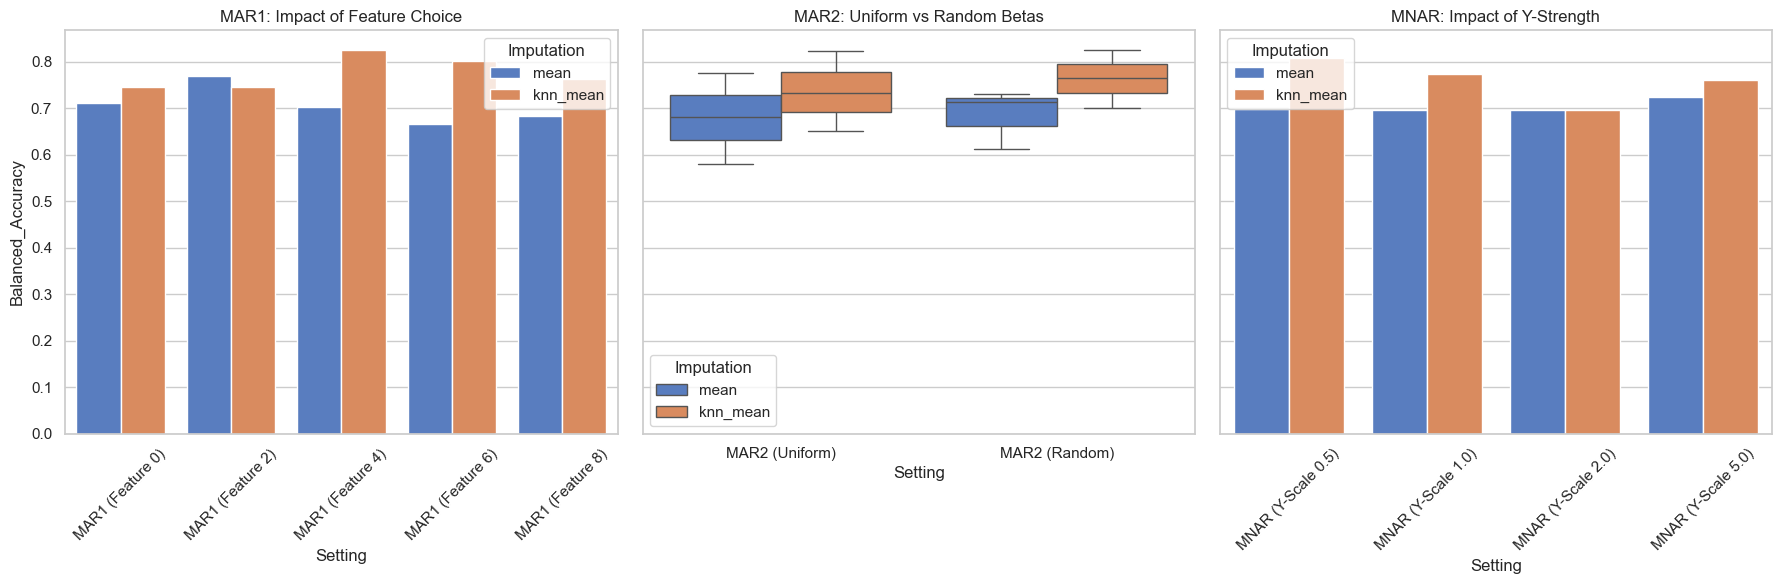

In [14]:
print("\n--- Summary Table: MAR1 Feature Choice ---")
mar1_df = df_res2[df_res2["Category"] == "MAR1 Variable Choice"]
display(mar1_df.groupby(["Setting", "Imputation"])["Balanced_Accuracy"].mean().unstack())

print("\n--- Summary Table: MAR2 Distributions (Averaged over seeds) ---")
mar2_df = df_res2[df_res2["Category"] == "MAR2 Distribution"]
display(mar2_df.groupby(["Setting", "Imputation"])["Balanced_Accuracy"].mean().unstack())

print("\n--- Summary Table: MNAR Y-Strength ---")
mnar_df = df_res2[df_res2["Category"] == "MNAR Y-Strength"]
display(mnar_df.groupby(["Setting", "Imputation"])["Balanced_Accuracy"].mean().unstack())

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

sns.barplot(data=mar1_df, x="Setting", y="Balanced_Accuracy", hue="Imputation", ax=axes[0])
axes[0].set_title("MAR1: Impact of Feature Choice")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=mar2_df, x="Setting", y="Balanced_Accuracy", hue="Imputation", ax=axes[1])
axes[1].set_title("MAR2: Uniform vs Random Betas")

sns.barplot(data=mnar_df, x="Setting", y="Balanced_Accuracy", hue="Imputation", ax=axes[2])
axes[2].set_title("MNAR: Impact of Y-Strength")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()